📊 상관계수 계산 중...

🔥 [주의] 상관관계가 높은(>0.8) 피처 쌍 목록:
 - in_degree <---> degree_1h : 0.9153
 - out_degree <---> degree_1h : 0.9265
 - out_degree <---> in_degree : 0.9839
 - cnt_1h <---> degree_1h : 0.9964
 - cnt_1h <---> in_degree : 0.9149
 - cnt_1h <---> out_degree : 0.9264
 - min_inter_tx_gap <---> time_delta_mean : 0.9090
 - max_1h <---> sum_1h : 0.9402
 - std_1h <---> sum_1h : 0.9269
 - std_1h <---> max_1h : 0.9852
 - sum_out_1h <---> sum_1h : 0.8923
 - sum_in_1h <---> sum_1h : 0.9454
 - sum_in_1h <---> max_1h : 0.9870
 - sum_in_1h <---> std_1h : 0.9833
 - cnt_small_tx <---> degree_1h : 0.9853
 - cnt_small_tx <---> in_degree : 0.9181
 - cnt_small_tx <---> out_degree : 0.9313
 - cnt_small_tx <---> cnt_1h : 0.9872
 - cnt_risk_format <---> degree_1h : 0.9924
 - cnt_risk_format <---> in_degree : 0.9119
 - cnt_risk_format <---> out_degree : 0.9255
 - cnt_risk_format <---> cnt_1h : 0.9960
 - cnt_risk_format <---> cnt_small_tx : 0.9837
 - cnt_24h <---> degree_1h : 0.9014
 - cnt_24h <---> in_degr

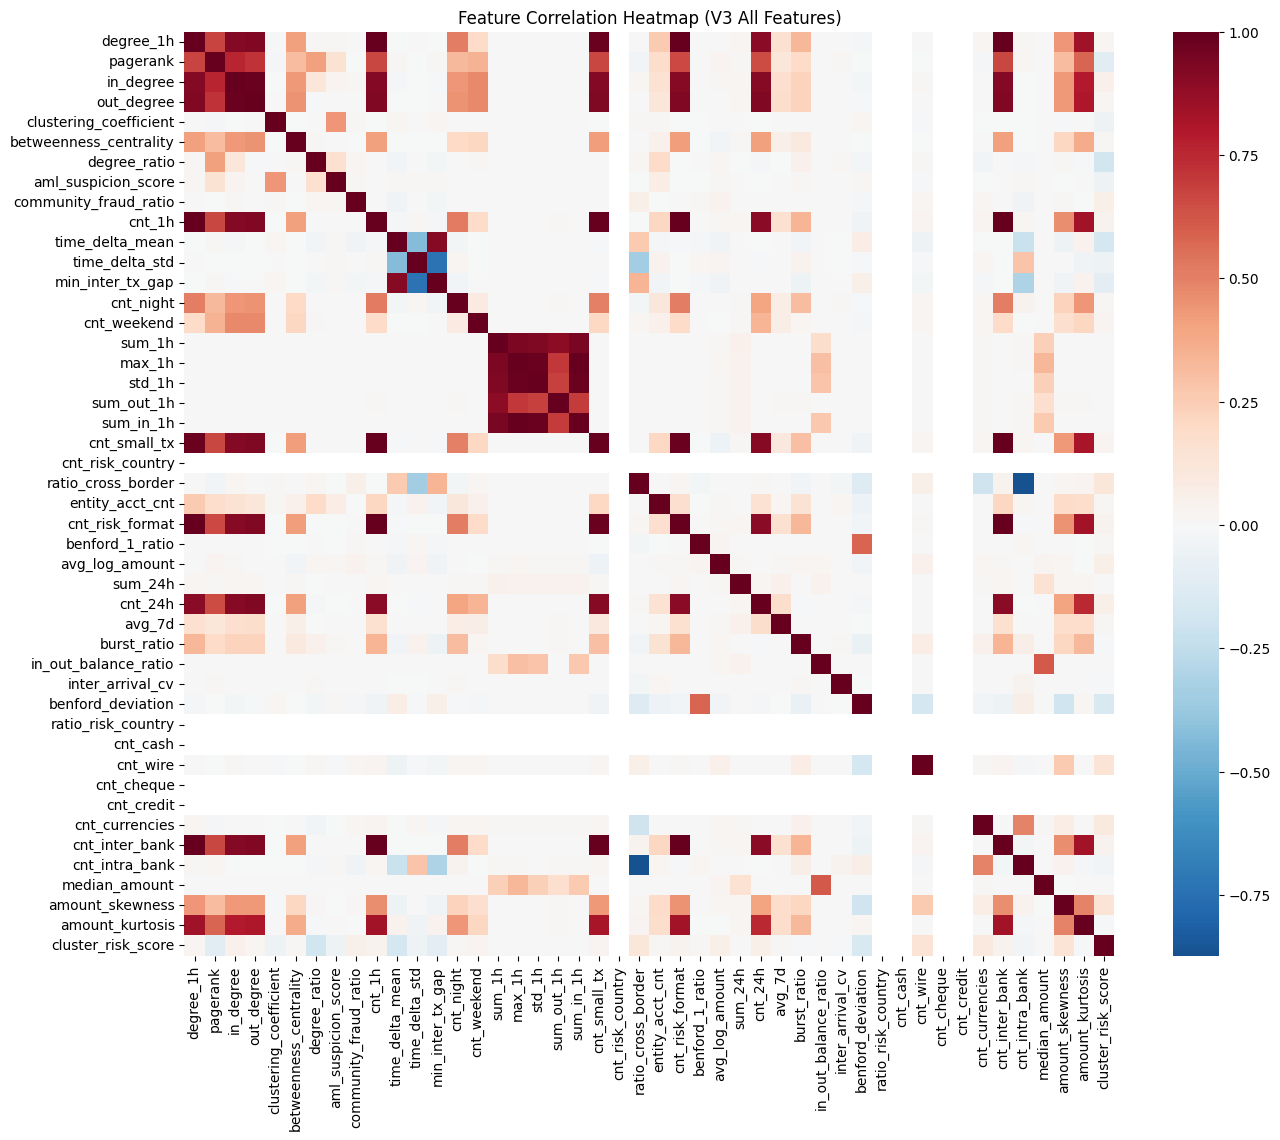

In [1]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 로드 및 통합 (학습했던 상태와 동일하게)
v2_path = "/home/tracerofjageum/aml_features_v2_integrated_final.parquet"
graph_path = "./graph_features_v3_fixed_no_leakage.parquet"

df_v2 = pl.read_parquet(v2_path)
df_graph = pl.read_parquet(graph_path)

# ID 타입 통일 및 조인
df_v2 = df_v2.with_columns(pl.col("account_id").cast(pl.String))
df_graph = df_graph.with_columns(pl.col("account_id").cast(pl.String))
df_all = df_v2.join(df_graph, on="account_id", how="left").fill_null(0)

# 2. 분석할 피처 리스트 (사용자님이 확인하신 46개)
features = [
    'degree_1h', 'pagerank', 'in_degree', 'out_degree', 'clustering_coefficient', 
    'betweenness_centrality', 'degree_ratio', 'aml_suspicion_score', 'community_fraud_ratio',
    'cnt_1h', 'time_delta_mean', 'time_delta_std', 'min_inter_tx_gap', 'cnt_night', 
    'cnt_weekend', 'sum_1h', 'max_1h', 'std_1h', 'sum_out_1h', 'sum_in_1h', 
    'cnt_small_tx', 'cnt_risk_country', 'ratio_cross_border', 'entity_acct_cnt', 
    'cnt_risk_format', 'benford_1_ratio', 'avg_log_amount', 'sum_24h', 'cnt_24h', 
    'avg_7d', 'burst_ratio', 'in_out_balance_ratio', 'inter_arrival_cv', 
    'benford_deviation', 'ratio_risk_country', 'cnt_cash', 'cnt_wire', 'cnt_cheque', 
    'cnt_credit', 'cnt_currencies', 'cnt_inter_bank', 'cnt_intra_bank', 
    'median_amount', 'amount_skewness', 'amount_kurtosis', 'cluster_risk_score'
]

# 3. 상관계수 계산 (메모리를 위해 pandas 변환 후 계산)
print("📊 상관계수 계산 중...")
corr_matrix = df_all.select(features).to_pandas().corr()

# 4. 고상관 피처 쌍 추출 (상관계수 > 0.8)
print("\n🔥 [주의] 상관관계가 높은(>0.8) 피처 쌍 목록:")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            pair = (corr_matrix.columns[i], corr_matrix.columns[j])
            score = corr_matrix.iloc[i, j]
            high_corr_pairs.append((pair, score))
            print(f" - {pair[0]} <---> {pair[1]} : {score:.4f}")

# 5. 시각화 (상위 상관관계 히트맵)
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, annot=False)
plt.title("Feature Correlation Heatmap (V3 All Features)")
plt.savefig("feature_correlation.png")
print("\n✅ 상관관계 히트맵이 'feature_correlation.png'로 저장되었습니다.")

# 중복되는거 제거하고 돌려보기(v3모델과 같은로직)


In [2]:
import polars as pl
import xgboost as xgb
import pandas as pd
import numpy as np
import gc
from sklearn.metrics import classification_report, average_precision_score
import warnings

warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# 1. 데이터 로드 및 통합 (V2 행동 + V3 그래프)
# -----------------------------------------------------------------------------
v2_path = "/home/tracerofjageum/aml_features_v2_integrated_final.parquet"
graph_path = "./graph_features_v3_fixed_no_leakage.parquet"

print("📂 데이터 로드 및 통합 중...")
df_v2 = pl.read_parquet(v2_path)
df_graph = pl.read_parquet(graph_path)

df_v2 = df_v2.with_columns(pl.col("account_id").cast(pl.String))
df_graph = df_graph.with_columns(pl.col("account_id").cast(pl.String))
df_all = df_v2.join(df_graph, on="account_id", how="left").fill_null(0)

del df_v2, df_graph; gc.collect()

# -----------------------------------------------------------------------------
# 2. 피처 다이어트 (상관계수 분석 기반 삭제 리스트)
# -----------------------------------------------------------------------------
# 중복 신호가 너무 강한 피처들을 삭제하여 모델의 혼선을 줄입니다.
remove_list = [
    # [거래 빈도 그룹] cnt_1h, cnt_risk_format과 0.99 이상 중복
    "in_degree", "out_degree", "degree_1h", "cnt_small_tx", "cnt_inter_bank",
    # [금액 규모 그룹] sum_1h와 0.94 이상 중복
    "max_1h", "std_1h", "sum_in_1h", "sum_out_1h",
    # [시간 간격 그룹] min_inter_tx_gap과 0.90 이상 중복
    "time_delta_mean"
]

# 기존 제외 리스트 (ID, 타겟, 누수 방지용)
exclude_cols = [
    "account_id", "time_group", "is_laundering", "mode_format", "currency_mode", 
    "Timestamp", "timestamp", "is_fraud_node_train", "community_id"
]

# 최종 학습 피처 확정
features = [c for c in df_all.columns if c not in exclude_cols and c not in remove_list]
target = "is_laundering"

print(f"\n✅ [V4 피처 다이어트 결과]")
print(f" - 전체 컬럼 수: {len(df_all.columns)}")
print(f" - 삭제된 중복 피처: {len(remove_list)}개 ({remove_list})")
print(f" - 최종 학습 피처 수: {len(features)}개")

# -----------------------------------------------------------------------------
# 3. 데이터 분할 및 DMatrix 생성 (노트북 로직 계승)
# -----------------------------------------------------------------------------
df_all = df_all.sort("time_group")
total_len = len(df_all)
train_end = int(total_len * 0.6)
val_end = int(total_len * 0.8)

train_pd = df_all[:train_end].select(features + [target]).to_pandas()
val_pd = df_all[train_end:val_end].select(features + [target]).to_pandas()
test_pd = df_all[val_end:].select(features + [target]).to_pandas()
test_full = df_all[val_end:]

dtrain = xgb.DMatrix(train_pd[features], label=train_pd[target])
dval = xgb.DMatrix(val_pd[features], label=val_pd[target])
dtest = xgb.DMatrix(test_pd[features], label=test_pd[target])

del df_all, train_pd, val_pd; gc.collect()

# -----------------------------------------------------------------------------
# 4. 통합 평가 함수 (V3와 1:1 비교용)
# -----------------------------------------------------------------------------
def run_eval(model, dmat, test_df_pl, name, threshold=0.7):
    probs = model.predict(dmat)
    y_true = dmat.get_label()
    y_pred = (probs > threshold).astype(int)
    
    print(f"\n🏆 [{name}] 평가 결과")
    print(classification_report(y_true, y_pred, digits=4))
    print(f"📌 AUPRC: {average_precision_score(y_true, probs):.4f}")
    
    # Top-K
    eval_df = pd.DataFrame({'prob': probs, 'actual': y_true})
    sorted_df = eval_df.sort_values(by='prob', ascending=False).reset_index(drop=True)
    for k in [100, 500, 1000]:
        hits = sorted_df.head(k)['actual'].sum()
        print(f"Top {k:<5} | 실제 범인: {int(hits):<6} | 정밀도: {hits/k:.2%}")

# -----------------------------------------------------------------------------
# 5. 모델 학습 (Basic & Tuned) - 하이퍼파라미터 완전 계승
# -----------------------------------------------------------------------------
print("\n🏋️ [V4 Basic] 학습 중 (가중치 424)...")
params_basic = {
    'objective': 'binary:logistic', 'eval_metric': 'aucpr',
    'max_depth': 6, 'learning_rate': 0.1, 'scale_pos_weight': 424,
    'tree_method': 'hist', 'random_state': 42
}
model_basic = xgb.train(params_basic, dtrain, num_boost_round=100)
run_eval(model_basic, dtest, test_full, "V4 Basic")

print("\n✨ [V4 Tuned] 학습 중 (가중치 100)...")
params_tuned = {
    'objective': 'binary:logistic', 'eval_metric': 'aucpr',
    'max_depth': 5, 'learning_rate': 0.05, 'scale_pos_weight': 100,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'random_state': 42
}
model_tuned = xgb.train(params_tuned, dtrain, num_boost_round=500,
                        evals=[(dval, 'val')], early_stopping_rounds=20, verbose_eval=False)
run_eval(model_tuned, dtest, test_full, "V4 Tuned")

# -----------------------------------------------------------------------------
# 6. 피처 중요도 확인
# -----------------------------------------------------------------------------
print("\n🔥 [V4 Tuned] 피처 중요도 Top 10")
imp = model_tuned.get_score(importance_type='gain')
for i, (f, s) in enumerate(sorted(imp.items(), key=lambda x: x[1], reverse=True)[:10]):
    print(f"{i+1:2d}. {f:<25} : {s:>12.2f}")

📂 데이터 로드 및 통합 중...

✅ [V4 피처 다이어트 결과]
 - 전체 컬럼 수: 53
 - 삭제된 중복 피처: 10개 (['in_degree', 'out_degree', 'degree_1h', 'cnt_small_tx', 'cnt_inter_bank', 'max_1h', 'std_1h', 'sum_in_1h', 'sum_out_1h', 'time_delta_mean'])
 - 최종 학습 피처 수: 36개

🏋️ [V4 Basic] 학습 중 (가중치 424)...

🏆 [V4 Basic] 평가 결과
              precision    recall  f1-score   support

         0.0     0.9987    0.9778    0.9881   5730722
         1.0     0.0940    0.6435    0.1640     20539

    accuracy                         0.9766   5751261
   macro avg     0.5463    0.8106    0.5761   5751261
weighted avg     0.9955    0.9766    0.9852   5751261

📌 AUPRC: 0.3285
Top 100   | 실제 범인: 100    | 정밀도: 100.00%
Top 500   | 실제 범인: 497    | 정밀도: 99.40%
Top 1000  | 실제 범인: 985    | 정밀도: 98.50%

✨ [V4 Tuned] 학습 중 (가중치 100)...

🏆 [V4 Tuned] 평가 결과
              precision    recall  f1-score   support

         0.0     0.9968    0.9999    0.9983   5730722
         1.0     0.7402    0.1154    0.1997     20539

    accuracy                      

In [3]:
import polars as pl
import xgboost as xgb
import pandas as pd
import numpy as np
import gc
from sklearn.metrics import classification_report, average_precision_score
import warnings

warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# 1. 데이터 로드 및 피처 다이어트 (V4 환경 유지)
# -----------------------------------------------------------------------------
v2_path = "/home/tracerofjageum/aml_features_v2_integrated_final.parquet"
graph_path = "./graph_features_v3_fixed_no_leakage.parquet"

df_v2 = pl.read_parquet(v2_path)
df_graph = pl.read_parquet(graph_path)

df_all = df_v2.join(df_graph.with_columns(pl.col("account_id").cast(pl.String)), on="account_id", how="left").fill_null(0)
del df_v2, df_graph; gc.collect()

# V4 삭제 리스트 (중복 피처 제거)
remove_list = ["in_degree", "out_degree", "degree_1h", "cnt_small_tx", "cnt_inter_bank",
               "max_1h", "std_1h", "sum_in_1h", "sum_out_1h", "time_delta_mean"]

exclude_cols = ["account_id", "time_group", "is_laundering", "mode_format", "currency_mode", 
                "Timestamp", "timestamp", "is_fraud_node_train", "community_id"]

features = [c for c in df_all.columns if c not in exclude_cols and c not in remove_list]
target = "is_laundering"

# -----------------------------------------------------------------------------
# 2. 데이터 분할
# -----------------------------------------------------------------------------
df_all = df_all.sort("time_group")
total_len = len(df_all)
train_end = int(total_len * 0.6)
val_end = int(total_len * 0.8)

train_pd = df_all[:train_end].select(features + [target]).to_pandas()
val_pd = df_all[train_end:val_end].select(features + [target]).to_pandas()
test_pd = df_all[val_end:].select(features + [target]).to_pandas()

dtrain = xgb.DMatrix(train_pd[features], label=train_pd[target])
dval = xgb.DMatrix(val_pd[features], label=val_pd[target])
dtest = xgb.DMatrix(test_pd[features], label=test_pd[target])

del df_all, train_pd, val_pd; gc.collect()

# -----------------------------------------------------------------------------
# 3. [V4 Re-Tuned] 새로운 파라미터로 학습
# -----------------------------------------------------------------------------
print(f"\n🚀 [V4 Re-Tuned] 학습 시작 (피처 {len(features)}개)")
print(f"⚙️ 주요 설정: scale_pos_weight=300, max_depth=7, learning_rate=0.05")

params_retuned = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'max_depth': 7,            # 깊이를 늘려 피처 간 상호작용 강화
    'learning_rate': 0.05,
    'scale_pos_weight': 300,   # Recall을 잡기 위해 다시 가중치 상향
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',
    'random_state': 42
}

# 검증셋을 통한 조기 종료 적용 (500 라운드)
model_retuned = xgb.train(
    params_retuned, 
    dtrain, 
    num_boost_round=500,
    evals=[(dval, 'val')],
    early_stopping_rounds=30,
    verbose_eval=100
)

# -----------------------------------------------------------------------------
# 4. 결과 평가 (V4 기존 결과와 비교)
# -----------------------------------------------------------------------------
probs = model_retuned.predict(dtest)
y_true = dtest.get_label()
threshold = 0.7
y_pred = (probs > threshold).astype(int)

print(f"\n" + "="*50)
print(f"🏆 [V4 Re-Tuned] 최종 성적표")
print("="*50)
print(classification_report(y_true, y_pred, digits=4))
print(f"📌 AUPRC: {average_precision_score(y_true, probs):.4f}")

# Top-K
eval_df = pd.DataFrame({'prob': probs, 'actual': y_true})
sorted_df = eval_df.sort_values(by='prob', ascending=False).reset_index(drop=True)
for k in [100, 500, 1000]:
    hits = sorted_df.head(k)['actual'].sum()
    print(f"Top {k:<5} | 실제 범인: {int(hits):<6} | 정밀도: {hits/k:.2%}")

# 피처 중요도
print(f"\n🔥 [V4 Re-Tuned] 피처 중요도 Top 5")
imp = model_retuned.get_score(importance_type='gain')
for i, (f, s) in enumerate(sorted(imp.items(), key=lambda x: x[1], reverse=True)[:5]):
    print(f"{i+1:2d}. {f:<25} : {s:>12.2f}")


🚀 [V4 Re-Tuned] 학습 시작 (피처 36개)
⚙️ 주요 설정: scale_pos_weight=300, max_depth=7, learning_rate=0.05
[0]	val-aucpr:0.08172
[100]	val-aucpr:0.28620
[200]	val-aucpr:0.31867
[300]	val-aucpr:0.33524
[400]	val-aucpr:0.34301
[493]	val-aucpr:0.34718

🏆 [V4 Re-Tuned] 최종 성적표
              precision    recall  f1-score   support

         0.0     0.9986    0.9847    0.9916   5730722
         1.0     0.1266    0.6174    0.2101     20539

    accuracy                         0.9834   5751261
   macro avg     0.5626    0.8011    0.6009   5751261
weighted avg     0.9955    0.9834    0.9888   5751261

📌 AUPRC: 0.3781
Top 100   | 실제 범인: 100    | 정밀도: 100.00%
Top 500   | 실제 범인: 498    | 정밀도: 99.60%
Top 1000  | 실제 범인: 990    | 정밀도: 99.00%

🔥 [V4 Re-Tuned] 피처 중요도 Top 5
 1. cnt_risk_format           :     28756.83
 2. ratio_cross_border        :     19024.60
 3. amount_kurtosis           :     18909.16
 4. community_fraud_ratio     :     10286.53
 5. cnt_wire                  :      7969.46


# 중복 제거 +중요도 낮은 피처 제거했을때 성능변화 확인

In [4]:
import pandas as pd

# 1. 모델로부터 전체 피처의 Gain Score 추출
# model_retuned는 방금 학습을 마친 모델 객체입니다.
importance = model_retuned.get_score(importance_type='gain')

# 2. 학습에 사용된 전체 피처 리스트 (XGBoost는 0점인 피처를 생략하므로 수동 확인 필요)
all_features = features # 위에서 정의한 36개 피처 리스트
feature_scores = {f: importance.get(f, 0) for f in all_features}

# 3. 데이터프레임으로 변환 및 정렬
imp_df = pd.DataFrame({
    'Feature': feature_scores.keys(),
    'Gain': feature_scores.values()
}).sort_values(by='Gain', ascending=True) # 낮은 순서대로 정렬

# 4. 누적 중요도 계산 (전체 정보량 중 해당 피처가 차지하는 % 확인)
total_gain = imp_df['Gain'].sum()
imp_df['Gain_Share (%)'] = (imp_df['Gain'] / total_gain) * 100
imp_df['Cumulative_Share (%)'] = imp_df['Gain_Share (%)'].cumsum()

print("="*65)
print(f"📉 [하위 15개 피처] 제거 시 성능 반등 가능성이 높은 후보군")
print("="*65)
# 하위 15개 출력
print(imp_df.head(15).to_string(index=False))

print("\n" + "="*65)
# 5. 제거 가이드라인 제시
low_impact_count = len(imp_df[imp_df['Gain_Share (%)'] < 0.5])
print(f"💡 분석 결과: 전체 정보 기여도가 0.5% 미만인 피처가 {low_impact_count}개 발견되었습니다.")
print("이 피처들은 제거해도 성능 하락이 거의 없으며, 오히려 모델의 집중력을 높일 수 있습니다.")
print("="*65)

📉 [하위 15개 피처] 제거 시 성능 반등 가능성이 높은 후보군
            Feature        Gain  Gain_Share (%)  Cumulative_Share (%)
   cnt_risk_country    0.000000        0.000000              0.000000
         cnt_cheque    0.000000        0.000000              0.000000
         cnt_credit    0.000000        0.000000              0.000000
 ratio_risk_country    0.000000        0.000000              0.000000
           cnt_cash    0.000000        0.000000              0.000000
             avg_7d   38.700443        0.025838              0.025838
    benford_1_ratio  548.435852        0.366163              0.392002
  benford_deviation  622.172791        0.415394              0.807396
            sum_24h  622.591553        0.415674              1.223069
            cnt_24h  900.291199        0.601080              1.824149
     time_delta_std  927.856506        0.619484              2.443633
        cnt_weekend 1025.074707        0.684392              3.128024
 cluster_risk_score 1059.628052        0.707461      

  Gain 이 0인것만 제거 

In [6]:
import polars as pl
import xgboost as xgb
import pandas as pd
import numpy as np
import gc
from sklearn.metrics import classification_report, average_precision_score
import warnings

warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# 1. 데이터 로드 및 통합
# -----------------------------------------------------------------------------
v2_path = "/home/tracerofjageum/aml_features_v2_integrated_final.parquet"
graph_path = "./graph_features_v3_fixed_no_leakage.parquet"

print("📂 데이터 로드 및 통합 중...")
df_all = pl.read_parquet(v2_path).join(
    pl.read_parquet(graph_path).with_columns(pl.col("account_id").cast(pl.String)), 
    on="account_id", how="left"
).fill_null(0)

# -----------------------------------------------------------------------------
# 2. 피처 선별 (V4 중복 제거 유지 + Gain 0 피처만 추가 제거)
# -----------------------------------------------------------------------------
# (1) V4 제거 리스트: 상관계수 0.9 이상 (모델의 판단 혼선 방지용)
remove_v4 = ["in_degree", "out_degree", "degree_1h", "cnt_small_tx", "cnt_inter_bank",
             "max_1h", "std_1h", "sum_in_1h", "sum_out_1h", "time_delta_mean"]

# (2) V5 제거 리스트: Gain 0.0 (모델이 아예 사용하지 않는 피처)
remove_zero_gain = ["cnt_risk_country", "cnt_cheque", "cnt_credit", "ratio_risk_country", "cnt_cash"]

# (3) 학습 제외 공통 컬럼
exclude_cols = ["account_id", "time_group", "is_laundering", "mode_format", "currency_mode", 
                "Timestamp", "timestamp", "is_fraud_node_train", "community_id"]

# 최종 학습 피처 확정 (총 31개)
features = [c for c in df_all.columns if c not in exclude_cols and c not in remove_v4 and c not in remove_zero_gain]
target = "is_laundering"

print(f"\n✅ [V5 피처 구성 업데이트]")
print(f" - 최종 학습 피처 수: {len(features)}개 (하위권 피처 10개 복구됨)")
print(f" - 제외 리스트: 중복 피처({len(remove_v4)}개) + 무의미 피처({len(remove_zero_gain)}개)")

# -----------------------------------------------------------------------------
# 3. 데이터 분할
# -----------------------------------------------------------------------------
df_all = df_all.sort("time_group")
total_len = len(df_all)
train_end, val_end = int(total_len * 0.6), int(total_len * 0.8)

train_pd = df_all[:train_end].select(features + [target]).to_pandas()
val_pd = df_all[train_end:val_end].select(features + [target]).to_pandas()
test_pd = df_all[val_end:].select(features + [target]).to_pandas()
test_full = df_all[val_end:]

dtrain = xgb.DMatrix(train_pd[features], label=train_pd[target])
dval = xgb.DMatrix(val_pd[features], label=val_pd[target])
dtest = xgb.DMatrix(test_pd[features], label=test_pd[target])

del df_all, train_pd, val_pd; gc.collect()

# -----------------------------------------------------------------------------
# 4. 통합 평가 함수 (F1, Recall, Daily Hits 모두 포함)
# -----------------------------------------------------------------------------
def run_full_eval(model, dmat, test_df_pl, name, threshold=0.7):
    probs = model.predict(dmat)
    y_true = dmat.get_label()
    y_pred = (probs > threshold).astype(int)
    
    print(f"\n" + "="*60)
    print(f"🏆 [{name}] 종합 평가 결과")
    print("="*60)
    
    # (1) Precision, Recall, F1
    print(classification_report(y_true, y_pred, digits=4))
    
    # (2) AUPRC
    auprc = average_precision_score(y_true, probs)
    print(f"📌 Final AUPRC: {auprc:.4f}")
    
    # (3) 전체 Top-K
    eval_df = pd.DataFrame({'prob': probs, 'actual': y_true})
    sorted_df = eval_df.sort_values(by='prob', ascending=False).reset_index(drop=True)
    print(f"\n[전체 Top-K 탐지 성능]")
    for k in [100, 500, 1000]:
        hits = sorted_df.head(k)['actual'].sum()
        print(f"Top {k:<5} | 실제 범인: {int(hits):<6} | 정밀도: {hits/k:.2%}")

    # (4) 일자별 Top-100
    eval_df['date'] = test_df_pl['time_group'].dt.date().to_pandas()
    daily_results = []
    for d in sorted(eval_df['date'].unique()):
        day_data = eval_df[eval_df['date'] == d]
        day_hits = day_data.sort_values(by='prob', ascending=False).head(100)['actual'].sum()
        daily_results.append({'Date': d, 'Hits@100': int(day_hits)})
    
    print(f"\n[일자별 Top-100 탐지 성능]")
    print(pd.DataFrame(daily_results).to_string(index=False))

# -----------------------------------------------------------------------------
# 5. 모델 학습 (V4 Re-Tuned 파라미터 계승)
# -----------------------------------------------------------------------------
params = {
    'objective': 'binary:logistic', 'eval_metric': 'aucpr',
    'max_depth': 7, 'learning_rate': 0.05, 'scale_pos_weight': 300,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'random_state': 42
}

print(f"\n🏋️ 모델 학습 시작...")
model_v5 = xgb.train(params, dtrain, num_boost_round=500,
                     evals=[(dval, 'val')], early_stopping_rounds=30, verbose_eval=100)

run_full_eval(model_v5, dtest, test_full, "V5 (Gain 0.0 Removed Only)")

📂 데이터 로드 및 통합 중...

✅ [V5 피처 구성 업데이트]
 - 최종 학습 피처 수: 31개 (하위권 피처 10개 복구됨)
 - 제외 리스트: 중복 피처(10개) + 무의미 피처(5개)

🏋️ 모델 학습 시작...
[0]	val-aucpr:0.07729
[100]	val-aucpr:0.28897
[200]	val-aucpr:0.31870
[300]	val-aucpr:0.33760
[400]	val-aucpr:0.34219
[499]	val-aucpr:0.34657

🏆 [V5 (Gain 0.0 Removed Only)] 종합 평가 결과
              precision    recall  f1-score   support

         0.0     0.9986    0.9849    0.9917   5730722
         1.0     0.1272    0.6147    0.2108     20539

    accuracy                         0.9836   5751261
   macro avg     0.5629    0.7998    0.6013   5751261
weighted avg     0.9955    0.9836    0.9889   5751261

📌 Final AUPRC: 0.3757

[전체 Top-K 탐지 성능]
Top 100   | 실제 범인: 100    | 정밀도: 100.00%
Top 500   | 실제 범인: 499    | 정밀도: 99.80%
Top 1000  | 실제 범인: 986    | 정밀도: 98.60%

[일자별 Top-100 탐지 성능]
      Date  Hits@100
2022-09-14        99
2022-09-15       100
2022-09-16        96
2022-09-17       100
2022-09-18       100
2022-09-19       100
2022-09-20       100
2022-09-21     

# 놓친 case 탐구

In [1]:
import polars as pl
import xgboost as xgb
import pandas as pd
import gc
from sklearn.metrics import average_precision_score

# 1. 데이터 로드 (딱 한 번만 수행)
print("📂 데이터 로딩 중...")
v2_path = "/home/tracerofjageum/aml_features_v2_integrated_final.parquet"
graph_path = "./graph_features_v3_fixed_no_leakage.parquet"

df_all = pl.read_parquet(v2_path).join(
    pl.read_parquet(graph_path).with_columns(pl.col("account_id").cast(pl.String)), 
    on="account_id", how="left"
).fill_null(0).sort("time_group")

# 2. 공통 설정 및 분할 지점
total_len = len(df_all)
train_end, val_end = int(total_len * 0.6), int(total_len * 0.8)
target = "is_laundering"

# -------------------------------------------------------------------------
# 3. [Step 1] V2 모델 학습 및 예측 (학습 후 즉시 메모리 삭제)
# -------------------------------------------------------------------------
exclude_v2 = ["account_id", "time_group", "is_laundering", "mode_format", "currency_mode", "Timestamp", "timestamp", "is_fraud_node_train"]
features_v2 = [c for c in df_all.columns if c in pl.read_parquet(v2_path).columns and c not in exclude_v2]

print("\n🏋️ [V2 모델] 학습 시작...")
dtrain_v2 = xgb.DMatrix(df_all[:train_end].select(features_v2).to_pandas(), label=df_all[:train_end][target].to_pandas())
dval_v2 = xgb.DMatrix(df_all[train_end:val_end].select(features_v2).to_pandas(), label=df_all[train_end:val_end][target].to_pandas())

params_v2 = {'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'max_depth': 5, 'learning_rate': 0.05, 'scale_pos_weight': 100, 'tree_method': 'hist', 'random_state': 42}
model_v2 = xgb.train(params_v2, dtrain_v2, num_boost_round=500, evals=[(dval_v2, 'val')], early_stopping_rounds=20, verbose_eval=False)

# 테스트 데이터 예측 및 DMatrix 삭제
dtest_v2 = xgb.DMatrix(df_all[val_end:].select(features_v2).to_pandas())
v2_probs = model_v2.predict(dtest_v2)

print("🧹 V2 메모리 정리 중...")
del dtrain_v2, dval_v2, dtest_v2, model_v2; gc.collect()

# -------------------------------------------------------------------------
# 4. [Step 2] V3 모델 학습 및 예측
# -------------------------------------------------------------------------
exclude_v3 = exclude_v2 + ["community_id"]
features_v3 = [c for c in df_all.columns if c not in exclude_v3]

print("\n🏋️ [V3 모델] 학습 시작...")
dtrain_v3 = xgb.DMatrix(df_all[:train_end].select(features_v3).to_pandas(), label=df_all[:train_end][target].to_pandas())
dval_v3 = xgb.DMatrix(df_all[train_end:val_end].select(features_v3).to_pandas(), label=df_all[train_end:val_end][target].to_pandas())

model_v3 = xgb.train(params_v2, dtrain_v3, num_boost_round=500, evals=[(dval_v3, 'val')], early_stopping_rounds=20, verbose_eval=False)

dtest_v3 = xgb.DMatrix(df_all[val_end:].select(features_v3).to_pandas())
v3_probs = model_v3.predict(dtest_v3)

print("🧹 V3 메모리 정리 중...")
del dtrain_v3, dval_v3, dtest_v3; gc.collect()

# -------------------------------------------------------------------------
# 5. [Step 3] 오답 심층 분석
# -------------------------------------------------------------------------
print("\n🎯 오답 케이스 분류 및 분석 중...")
test_results = df_all[val_end:].with_columns([
    pl.Series("v2_prob", v2_probs),
    pl.Series("v3_prob", v3_probs)
])

threshold = 0.7
# 케이스 분류
lost_by_v3 = test_results.filter((pl.col(target) == 1) & (pl.col("v2_prob") >= threshold) & (pl.col("v3_prob") < threshold))
recovered_by_v3 = test_results.filter((pl.col(target) == 1) & (pl.col("v2_prob") < threshold) & (pl.col("v3_prob") >= threshold))
missed_by_both = test_results.filter((pl.col(target) == 1) & (pl.col("v2_prob") < threshold) & (pl.col("v3_prob") < threshold))

print(f"\n" + "="*50)
print(f"📊 [오답 분석 결과]")
print(f"1. V3가 놓친 범인 (V2는 검거): {len(lost_by_v3)}건")
print(f"2. V3만 새로 잡은 범인 (V2는 실패): {len(recovered_by_v3)}건")
print(f"3. 둘 다 놓친 지능범: {len(missed_by_both)}건")
print("="*50)

# 핵심 피처 비교 분석
comparison_cols = ["sum_1h", "cnt_1h", "community_fraud_ratio", "betweenness_centrality"]
print("\n🔥 [Case 1] V3가 놓친 범인들의 특징 (왜 놓쳤나?)")
print(lost_by_v3.select(comparison_cols).mean())

print("\n🔥 [Case 3] 둘 다 놓친 범인들의 특징 (우리의 다음 타겟)")
print(missed_by_both.select(comparison_cols).mean())

📂 데이터 로딩 중...

🏋️ [V2 모델] 학습 시작...
🧹 V2 메모리 정리 중...

🏋️ [V3 모델] 학습 시작...
🧹 V3 메모리 정리 중...

🎯 오답 케이스 분류 및 분석 중...

📊 [오답 분석 결과]
1. V3가 놓친 범인 (V2는 검거): 5463건
2. V3만 새로 잡은 범인 (V2는 실패): 788건
3. 둘 다 놓친 지능범: 3312건

🔥 [Case 1] V3가 놓친 범인들의 특징 (왜 놓쳤나?)
shape: (1, 4)
┌──────────┬──────────┬───────────────────────┬────────────────────────┐
│ sum_1h   ┆ cnt_1h   ┆ community_fraud_ratio ┆ betweenness_centrality │
│ ---      ┆ ---      ┆ ---                   ┆ ---                    │
│ f64      ┆ f64      ┆ f64                   ┆ f64                    │
╞══════════╪══════════╪═══════════════════════╪════════════════════════╡
│ 3.6498e7 ┆ 2.498993 ┆ 0.001615              ┆ 0.000003               │
└──────────┴──────────┴───────────────────────┴────────────────────────┘

🔥 [Case 3] 둘 다 놓친 범인들의 특징 (우리의 다음 타겟)
shape: (1, 4)
┌──────────┬──────────┬───────────────────────┬────────────────────────┐
│ sum_1h   ┆ cnt_1h   ┆ community_fraud_ratio ┆ betweenness_centrality │
│ ---      ┆ ---      ┆ ---     

In [1]:
import polars as pl
import xgboost as xgb
import pandas as pd
import gc

# 1. 데이터 로드 및 통합
v2_path = "/home/tracerofjageum/aml_features_v2_integrated_final.parquet"
graph_path = "./graph_features_v3_fixed_no_leakage.parquet"

print("📂 데이터 통합 중...")
df_all = pl.read_parquet(v2_path).join(
    pl.read_parquet(graph_path).with_columns(pl.col("account_id").cast(pl.String)), 
    on="account_id", how="left"
).fill_null(0).sort("time_group")

# 분석용 20개 핵심 피처
analysis_features = [
    "sum_1h", "cnt_1h", "max_1h", "ratio_cross_border", "cnt_risk_format", 
    "degree_1h", "entity_acct_cnt", "cnt_intra_bank", "cnt_wire", "cnt_night", 
    "burst_ratio", "amount_kurtosis", "sum_in_1h", "sum_out_1h", "avg_log_amount",
    "community_fraud_ratio", "pagerank", "betweenness_centrality", "clustering_coefficient", "aml_suspicion_score"
]

total_len = len(df_all)
train_end, val_end = int(total_len * 0.6), int(total_len * 0.8)
target = "is_laundering"

# -------------------------------------------------------------------------
# 2. 모델 학습 (V2, V3 순차 진행)
# -------------------------------------------------------------------------
params = {'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'max_depth': 5, 'learning_rate': 0.05, 'scale_pos_weight': 100, 'tree_method': 'hist', 'random_state': 42}

# [V2 학습]
exclude_v2 = ["account_id", "time_group", "is_laundering", "mode_format", "currency_mode", "Timestamp", "timestamp", "is_fraud_node_train"]
features_v2 = [c for c in df_all.columns if c in pl.read_parquet(v2_path).columns and c not in exclude_v2]

print("🏋️ V2 학습 중...")
dtrain = xgb.DMatrix(df_all[:train_end].select(features_v2).to_pandas(), label=df_all[:train_end][target].to_pandas())
dval = xgb.DMatrix(df_all[train_end:val_end].select(features_v2).to_pandas(), label=df_all[train_end:val_end][target].to_pandas())
model_v2 = xgb.train(params, dtrain, num_boost_round=500, evals=[(dval, 'val')], early_stopping_rounds=20, verbose_eval=False)
v2_probs = model_v2.predict(xgb.DMatrix(df_all[val_end:].select(features_v2).to_pandas()))
del dtrain, dval, model_v2; gc.collect()

# [V3 학습]
exclude_v3 = exclude_v2 + ["community_id"]
features_v3 = [c for c in df_all.columns if c not in exclude_v3]

print("🏋️ V3 학습 중...")
dtrain = xgb.DMatrix(df_all[:train_end].select(features_v3).to_pandas(), label=df_all[:train_end][target].to_pandas())
dval = xgb.DMatrix(df_all[train_end:val_end].select(features_v3).to_pandas(), label=df_all[train_end:val_end][target].to_pandas())
model_v3 = xgb.train(params, dtrain, num_boost_round=500, evals=[(dval, 'val')], early_stopping_rounds=20, verbose_eval=False)
v3_probs = model_v3.predict(xgb.DMatrix(df_all[val_end:].select(features_v3).to_pandas()))
del dtrain, dval, model_v3; gc.collect()

# -------------------------------------------------------------------------
# 3. 모든 결과 저장 (재사용을 위한 핵심 단계)
# -------------------------------------------------------------------------
print("💾 분석 결과 저장 중...")
# 테스트 세트 데이터 + V2예측값 + V3예측값을 하나의 파일로 저장
test_results = df_all[val_end:].with_columns([
    pl.Series("v2_prob", v2_probs),
    pl.Series("v3_prob", v3_probs)
])

# 분석에 필요한 컬럼들만 추려서 저장 (용량 절감)
save_cols = list(set(analysis_features + ["v2_prob", "v3_prob", "is_laundering", "time_group", "account_id", "community_id"]))
test_results.select(save_cols).write_parquet("test_analysis_results.parquet")
print("✅ 저장 완료: 'test_analysis_results.parquet'")

# -------------------------------------------------------------------------
# 4. 20개 피처 풀스케일 분석
# -------------------------------------------------------------------------
threshold = 0.7
cases = {
    "V3_Lost": test_results.filter((pl.col(target) == 1) & (pl.col("v2_prob") >= threshold) & (pl.col("v3_prob") < threshold)),
    "Recovered": test_results.filter((pl.col(target) == 1) & (pl.col("v2_prob") < threshold) & (pl.col("v3_prob") >= threshold)),
    "Missed_Both": test_results.filter((pl.col(target) == 1) & (pl.col("v2_prob") < threshold) & (pl.col("v3_prob") < threshold))
}

report = []
for name, df in cases.items():
    stats = df.select([pl.col(c).mean() for c in analysis_features]).to_pandas()
    stats.index = [name]
    report.append(stats)

final_report = pd.concat(report).T
print("\n📊 [V2 vs V3] 20개 핵심 피처 비교 리포트")
print(final_report)

# V3가 놓친 놈들의 특징(Bias) 분석
final_report['Bias_Index'] = final_report['V3_Lost'] / final_report['Recovered']
print("\n💡 V3 모델이 '무시'해버린 핵심 신호 Top 5")
print(final_report[['Bias_Index']].sort_values(by='Bias_Index', ascending=False).head(5))

📂 데이터 통합 중...
🏋️ V2 학습 중...
🏋️ V3 학습 중...
💾 분석 결과 저장 중...
✅ 저장 완료: 'test_analysis_results.parquet'

📊 [V2 vs V3] 20개 핵심 피처 비교 리포트
                             V3_Lost     Recovered   Missed_Both
sum_1h                  3.649850e+07  9.156448e+06  7.580963e+06
cnt_1h                  2.498993e+00  2.270305e+00  1.696256e+00
max_1h                  3.438571e+07  8.887945e+06  6.255979e+06
ratio_cross_border      8.664674e-01  9.701142e-01  9.803493e-01
cnt_risk_format         6.150467e-02  8.083756e-01  5.987319e-01
degree_1h               2.160535e+00  1.643401e+00  1.192633e+00
entity_acct_cnt         1.910672e+00  1.090102e+00  1.134058e+00
cnt_intra_bank          4.204649e-01  7.233503e-02  6.400966e-02
cnt_wire                2.562694e-03  1.522843e-02  1.328502e-02
cnt_night               4.257734e-01  2.829949e-01  3.955314e-01
burst_ratio             2.196304e+00  9.186972e-01  1.248259e+00
amount_kurtosis        -3.404148e-01  4.351552e-01 -5.745041e-01
sum_in_1h               2

In [3]:
import polars as pl
import pandas as pd

# 1. 저장된 분석용 데이터 로드
results = pl.read_parquet("test_analysis_results.parquet")

# 2. 분석할 20개 핵심 피처 리스트
analysis_features = [
    "sum_1h", "cnt_1h", "max_1h", "ratio_cross_border", "cnt_risk_format", 
    "degree_1h", "entity_acct_cnt", "cnt_intra_bank", "cnt_wire", "cnt_night", 
    "burst_ratio", "amount_kurtosis", "sum_in_1h", "sum_out_1h", "avg_log_amount",
    "community_fraud_ratio", "pagerank", "betweenness_centrality", "clustering_coefficient", "aml_suspicion_score"
]

# 3. 케이스 분류 (Threshold 0.7 기준)
threshold = 0.7
target = "is_laundering"

cases = {
    "V3_Lost": results.filter((pl.col(target) == 1) & (pl.col("v2_prob") >= threshold) & (pl.col("v3_prob") < threshold)),
    "V3_Recovered": results.filter((pl.col(target) == 1) & (pl.col("v2_prob") < threshold) & (pl.col("v3_prob") >= threshold)),
    "Missed_Both": results.filter((pl.col(target) == 1) & (pl.col("v2_prob") < threshold) & (pl.col("v3_prob") < threshold)),
    "All_Launderers": results.filter(pl.col(target) == 1)
}

# 4. 각 케이스별 평균값 계산 및 리포트 생성
report_list = []
for name, case_df in cases.items():
    # 데이터가 있는 경우만 평균 계산
    if case_df.height > 0:
        stats = case_df.select([pl.col(c).mean() for c in analysis_features if c in case_df.columns]).to_pandas()
        stats.index = [name]
        report_list.append(stats)

final_report = pd.concat(report_list).T

# 5. 결과 출력
print("\n" + "="*90)
print(f"{'Feature Name':<25} | {'V3_Lost':>12} | {'Recovered':>12} | {'Missed_Both':>12}")
print("-" * 90)
for idx, row in final_report.iterrows():
    print(f"{idx:<25} | {row['V3_Lost']:>12.4f} | {row['V3_Recovered']:>12.4f} | {row['Missed_Both']:>12.4f}")
print("="*90)

# V3의 판단 편향 확인 (V3_Lost / V3_Recovered 비율)
final_report['Bias_Index'] = final_report['V3_Lost'] / final_report['V3_Recovered']
print("\n💡 V3 모델이 놓친 범인들이 가졌던 강력한 신호 (Bias Index Top 5)")
print(final_report[['Bias_Index']].sort_values(by='Bias_Index', ascending=False).head(5))


Feature Name              |      V3_Lost |    Recovered |  Missed_Both
------------------------------------------------------------------------------------------
sum_1h                    | 36498498.4363 | 9156448.1142 | 7580962.6240
cnt_1h                    |       2.4990 |       2.2703 |       1.6963
max_1h                    | 34385710.0199 | 8887945.4848 | 6255979.0720
ratio_cross_border        |       0.8665 |       0.9701 |       0.9803
cnt_risk_format           |       0.0615 |       0.8084 |       0.5987
degree_1h                 |       2.1605 |       1.6434 |       1.1926
entity_acct_cnt           |       1.9107 |       1.0901 |       1.1341
cnt_intra_bank            |       0.4205 |       0.0723 |       0.0640
cnt_wire                  |       0.0026 |       0.0152 |       0.0133
cnt_night                 |       0.4258 |       0.2830 |       0.3955
burst_ratio               |       2.1963 |       0.9187 |       1.2483
amount_kurtosis           |      -0.3404 |       0.435

In [4]:
import polars as pl
import pandas as pd

# 1. 저장된 분석 데이터 로드
results = pl.read_parquet("test_analysis_results.parquet")

# 2. 분석 피처 리스트
analysis_features = [
    "sum_1h", "cnt_1h", "ratio_cross_border", "cnt_risk_format", 
    "community_fraud_ratio", "pagerank", "betweenness_centrality", 
    "clustering_coefficient", "aml_suspicion_score"
]

# 3. V2가 놓친 케이스 정의 (Threshold 0.7 기준)
threshold = 0.7
target = "is_laundering"

# V2는 놓쳤으나 V3는 잡은 '관계 중심 사기'
recovered_by_v3 = results.filter((pl.col(target) == 1) & (pl.col("v2_prob") < threshold) & (pl.col("v3_prob") >= threshold))

# V2, V3 모두 놓친 '지능형 스텔스 사기'
missed_both = results.filter((pl.col(target) == 1) & (pl.col("v2_prob") < threshold) & (pl.col("v3_prob") < threshold))

# [대조군] V2가 아주 잘 잡은 '거물 사기'
caught_by_v2 = results.filter((pl.col(target) == 1) & (pl.col("v2_prob") >= threshold))

# 4. 분석 리포트 생성
report_data = []
for name, df in [("V2_Missed_V3_Caught", recovered_by_v3), ("Missed_Both", missed_both), ("V2_Caught_Total", caught_by_v2)]:
    if df.height > 0:
        stats = df.select([pl.col(c).mean() for c in analysis_features]).to_pandas()
        stats.index = [name]
        report_data.append(stats)

final_report = pd.concat(report_data).T

print("\n" + "="*80)
print("📊 [V2 모델 오답 분석] V2는 왜 이들을 놓쳤는가?")
print("="*80)
print(final_report)
print("="*80)

# 5. V2의 탐지 실패 원인(Gap) 계산
final_report['V2_Gap_Ratio'] = final_report['V2_Caught_Total'] / final_report['V2_Missed_V3_Caught']
print("\n💡 V2가 잡은 놈들에 비해 놓친 놈들이 가진 특징 (Gap Top 3)")
# 비율이 낮을수록 V2가 해당 신호를 무시하고 있다는 뜻
print(final_report[['V2_Gap_Ratio']].sort_values(by='V2_Gap_Ratio').head(3))


📊 [V2 모델 오답 분석] V2는 왜 이들을 놓쳤는가?
                        V2_Missed_V3_Caught   Missed_Both  V2_Caught_Total
sum_1h                         9.156448e+06  7.580963e+06     2.851152e+08
cnt_1h                         2.270305e+00  1.696256e+00     3.087323e+01
ratio_cross_border             9.701142e-01  9.803493e-01     8.102328e-01
cnt_risk_format                8.083756e-01  5.987319e-01     2.002360e+01
community_fraud_ratio          3.362511e-02  1.059859e-02     1.648900e-02
pagerank                       6.666300e-07  4.864268e-07     1.641250e-06
betweenness_centrality         1.851017e-05  4.922106e-06     5.640759e-04
clustering_coefficient         3.459421e-02  1.379714e-02     1.569494e-02
aml_suspicion_score            1.384735e-05  5.107448e-06     6.406375e-06

💡 V2가 잡은 놈들에 비해 놓친 놈들이 가진 특징 (Gap Top 3)
                        V2_Gap_Ratio
clustering_coefficient      0.453687
aml_suspicion_score         0.462643
community_fraud_ratio       0.490378


# v2와 v3 앙상블

In [5]:
import polars as pl
from sklearn.metrics import average_precision_score

# 1. 저장된 데이터 로드
results = pl.read_parquet("test_analysis_results.parquet")

# 2. 아주 단순한 앙상블 (단순 산술 평균)
# V2와 V3의 예측치를 5:5로 섞어봅니다.
results = results.with_columns([
    ((pl.col("v2_prob") + pl.col("v3_prob")) / 2).alias("ensemble_prob")
])

# 3. 성능 비교
v2_auprc = average_precision_score(results["is_laundering"], results["v2_prob"])
v3_auprc = average_precision_score(results["is_laundering"], results["v3_prob"])
ensemble_auprc = average_precision_score(results["is_laundering"], results["ensemble_prob"])

print(f"📊 V2 AUPRC: {v2_auprc:.4f}")
print(f"📊 V3 AUPRC: {v3_auprc:.4f}")
print(f"🔥 Ensemble AUPRC: {ensemble_auprc:.4f}")

📊 V2 AUPRC: 0.5480
📊 V3 AUPRC: 0.3698
🔥 Ensemble AUPRC: 0.4444


In [6]:
import polars as pl
from sklearn.metrics import average_precision_score
import numpy as np

# 1. 저장된 데이터 로드
results = pl.read_parquet("test_analysis_results.parquet")

print("🔍 최적의 앙상블 비율 찾는 중...")
best_auprc = 0
best_weight = 0

# V2의 가중치를 0.1부터 0.9까지 변화시키며 테스트
for w in np.arange(0.1, 1.0, 0.1):
    v2_w = round(w, 1)
    v3_w = round(1 - w, 1)
    
    ensemble_prob = (results["v2_prob"] * v2_w) + (results["v3_prob"] * v3_w)
    auprc = average_precision_score(results["is_laundering"], ensemble_prob)
    
    print(f"⚖️ 비율 [V2:{v2_w} | V3:{v3_w}] -> AUPRC: {auprc:.4f}")
    
    if auprc > best_auprc:
        best_auprc = auprc
        best_weight = v2_w

print(f"\n🏆 최적 조합: V2({best_weight}) + V3({round(1-best_weight, 1)})")
print(f"🚀 최고 AUPRC: {best_auprc:.4f} (기존 V2: 0.5480)")

🔍 최적의 앙상블 비율 찾는 중...
⚖️ 비율 [V2:0.1 | V3:0.9] -> AUPRC: 0.3936
⚖️ 비율 [V2:0.2 | V3:0.8] -> AUPRC: 0.4108
⚖️ 비율 [V2:0.3 | V3:0.7] -> AUPRC: 0.4238
⚖️ 비율 [V2:0.4 | V3:0.6] -> AUPRC: 0.4343
⚖️ 비율 [V2:0.5 | V3:0.5] -> AUPRC: 0.4444
⚖️ 비율 [V2:0.6 | V3:0.4] -> AUPRC: 0.4557
⚖️ 비율 [V2:0.7 | V3:0.3] -> AUPRC: 0.4700
⚖️ 비율 [V2:0.8 | V3:0.2] -> AUPRC: 0.4891
⚖️ 비율 [V2:0.9 | V3:0.1] -> AUPRC: 0.5170

🏆 최적 조합: V2(0.9) + V3(0.1)
🚀 최고 AUPRC: 0.5170 (기존 V2: 0.5480)


In [7]:
import polars as pl
import numpy as np
from sklearn.metrics import average_precision_score
from scipy.stats import rankdata

# 1. 데이터 로드
results = pl.read_parquet("test_analysis_results.parquet")
y_true = results["is_laundering"].to_numpy()
v2_p = results["v2_prob"].to_numpy()
v3_p = results["v3_prob"].to_numpy()

# -------------------------------------------------------------------------
# 기법 1: Rank Averaging (순위 평균)
# -------------------------------------------------------------------------
v2_rank = rankdata(v2_p) / len(v2_p)
v3_rank = rankdata(v3_p) / len(v3_p)
rank_ensemble_p = (v2_rank + v3_rank) / 2
rank_auprc = average_precision_score(y_true, rank_ensemble_p)

# -------------------------------------------------------------------------
# 기법 2: Max Pooling (둘 중 하나라도 높으면 사기)
# -------------------------------------------------------------------------
max_ensemble_p = np.maximum(v2_p, v3_p)
max_auprc = average_precision_score(y_true, max_ensemble_p)

# -------------------------------------------------------------------------
# 기법 3: Power Mean (V2에게 가중치를 주면서 V3의 힌트만 참고)
# -------------------------------------------------------------------------
# V2의 영향력을 키우기 위해 제곱을 하여 가중합
power_ensemble_p = (v2_p**2 + v3_p * 0.1) 
power_auprc = average_precision_score(y_true, power_ensemble_p)

print(f"📊 [Baseline] V2 AUPRC : {average_precision_score(y_true, v2_p):.4f}")
print("-" * 50)
print(f"🚀 [Method 1] Rank Ensemble  : {rank_auprc:.4f}")
print(f"🚀 [Method 2] Max Ensemble   : {max_auprc:.4f}")
print(f"🚀 [Method 3] Power/Heuristic: {power_auprc:.4f}")

📊 [Baseline] V2 AUPRC : 0.5480
--------------------------------------------------
🚀 [Method 1] Rank Ensemble  : 0.4229
🚀 [Method 2] Max Ensemble   : 0.5496
🚀 [Method 3] Power/Heuristic: 0.5362


In [1]:
import polars as pl
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, average_precision_score

# 1. 저장된 분석 데이터 로드
results = pl.read_parquet("test_analysis_results.parquet")

# 2. Max Ensemble 계산 (V2와 V3 중 높은 점수 채택)
results = results.with_columns([
    pl.max_horizontal("v2_prob", "v3_prob").alias("ensemble_prob")
])

# 3. 종합 성능 평가 (Threshold 0.7 적용)
y_true = results["is_laundering"].to_numpy()
y_prob = results["ensemble_prob"].to_numpy()
y_pred = (y_prob >= 0.7).astype(int)

print("\n" + "="*65)
print("🏆 [Max Ensemble: V2 + V3] 종합 평가 결과 (Threshold: 0.7)")
print("="*65)
# F1-score 포함 전체 리포트
print(classification_report(y_true, y_pred, digits=4))

auprc = average_precision_score(y_true, y_prob)
print(f"📌 Final AUPRC: {auprc:.4f}")

# 4. 전체 Top-K 탐지 성능 (Precision 중심)
print("\n[전체 Top-K 탐지 성능]")
print("-" * 45)
for k in [100, 500, 1000, 5000]:
    top_k_df = results.sort("ensemble_prob", descending=True).head(k)
    hits = top_k_df["is_laundering"].sum()
    precision = (hits / k) * 100
    print(f"Top {k:<5} | 실제 범인: {int(hits):<5} | 정밀도: {precision:>7.2f}%")

# 5. 시간 그룹별(일별 대용) Top-100 탐지 성능
# Timestamp 대신 사용 가능한 time_group 활용
print("\n[시간 그룹별 Top-100 탐지 성능]")
print("-" * 35)
time_groups = sorted(results["time_group"].unique().to_list())
group_eval = []

for tg in time_groups:
    group_data = results.filter(pl.col("time_group") == tg)
    k_val = min(100, group_data.height)
    # 해당 시간 그룹 내 상위 100개 중 실제 사기 계좌 수
    hits = group_data.sort("ensemble_prob", descending=True).head(k_val)["is_laundering"].sum()
    group_eval.append({
        "TimeGroup": tg, 
        "Hits@100": int(hits), 
        "Prec@100": f"{(hits/k_val)*100:.1f}%"
    })

print(pd.DataFrame(group_eval).to_string(index=False))


🏆 [Max Ensemble: V2 + V3] 종합 평가 결과 (Threshold: 0.7)
              precision    recall  f1-score   support

       False     0.9994    0.9835    0.9914   5730722
        True     0.1539    0.8387    0.2600     20539

    accuracy                         0.9830   5751261
   macro avg     0.5766    0.9111    0.6257   5751261
weighted avg     0.9964    0.9830    0.9888   5751261

📌 Final AUPRC: 0.5496

[전체 Top-K 탐지 성능]
---------------------------------------------
Top 100   | 실제 범인: 100   | 정밀도:  100.00%
Top 500   | 실제 범인: 499   | 정밀도:   99.80%
Top 1000  | 실제 범인: 993   | 정밀도:   99.30%
Top 5000  | 실제 범인: 4645  | 정밀도:   92.90%

[시간 그룹별 Top-100 탐지 성능]
-----------------------------------
          TimeGroup  Hits@100 Prec@100
2022-09-14 05:00:00         3     3.0%
2022-09-14 06:00:00        57    57.0%
2022-09-14 07:00:00        61    61.0%
2022-09-14 08:00:00        69    69.0%
2022-09-14 09:00:00        62    62.0%
2022-09-14 10:00:00        73    73.0%
2022-09-14 11:00:00        82    82.0

In [3]:
import polars as pl
import pandas as pd
from datetime import datetime

# 1. 데이터 로드
results = pl.read_parquet("test_analysis_results.parquet")

# 2. [중요] ensemble_prob 컬럼 생성 (에러 방지)
# V2와 V3 중 더 높은 점수를 앙상블 점수로 사용합니다.
results = results.with_columns([
    pl.max_horizontal("v2_prob", "v3_prob").alias("ensemble_prob")
])

# 3. 날짜 필터링 (Polars datetime 객체로 비교)
cutoff_date = datetime(2022, 9, 17, 0, 0, 0)
early_period = results.filter(pl.col("time_group") < cutoff_date)
late_period = results.filter(pl.col("time_group") >= cutoff_date)

# 4. 그룹 정의 (Threshold 0.7 기준)
threshold = 0.7

# 초반에 놓친 사기꾼 (실제 1인데 모델 점수 0.7 미만)
early_missed = early_period.filter((pl.col("is_laundering") == 1) & (pl.col("ensemble_prob") < threshold))
# 초반에도 잡아낸 사기꾼 (실제 1이고 모델 점수 0.7 이상)
early_caught = early_period.filter((pl.col("is_laundering") == 1) & (pl.col("ensemble_prob") >= threshold))
# 후반에 잘 잡는 사기꾼 (실제 1이고 모델 점수 0.7 이상)
late_caught = late_period.filter((pl.col("is_laundering") == 1) & (pl.col("ensemble_prob") >= threshold))

# 5. 분석 대상 피처 (에러 메시지에 나온 컬럼들 중 핵심 추출)
analysis_features = [
    "sum_1h", "max_1h", "cnt_1h", "avg_log_amount",  # 통계
    "degree_1h", "clustering_coefficient", "community_fraud_ratio", # 그래프
    "cnt_risk_format", "ratio_cross_border" # 리스크
]

# 6. 리포트 생성 및 출력
report_data = []
for name, target_df in [("Early_Missed (오답)", early_missed), 
                        ("Early_Caught (정답)", early_caught), 
                        ("Late_Caught (후반정답)", late_caught)]:
    if target_df.height > 0:
        stats = target_df.select([pl.col(c).mean().alias(c) for c in analysis_features]).to_pandas()
        stats.index = [name]
        report_data.append(stats)

if report_data:
    comparison_table = pd.concat(report_data).T
    print("\n" + "="*85)
    print("🚨 [초반 탐지 실패 분석] 왜 9/14~16에는 사기꾼을 놓쳤는가?")
    print("="*85)
    print(comparison_table)
    print("-" * 85)
    
    print(f"\n📊 규모 확인:")
    print(f"- 초반에 '몰랐던' 사기꾼: {early_missed.height}명")
    print(f"- 초반에도 '알았던' 사기꾼: {early_caught.height}명")
else:
    print("❌ 분석할 데이터가 부족합니다.")


🚨 [초반 탐지 실패 분석] 왜 9/14~16에는 사기꾼을 놓쳤는가?
                        Early_Missed (오답)  Early_Caught (정답)  \
sum_1h                       8.840291e+06       1.014756e+08   
max_1h                       7.292341e+06       5.625867e+07   
cnt_1h                       1.798165e+00       5.137944e+01   
avg_log_amount               7.880555e+00       9.425506e+00   
degree_1h                    1.219831e+00       2.683235e+01   
clustering_coefficient       1.460773e-02       1.651624e-02   
community_fraud_ratio        1.101842e-02       1.779283e-02   
cnt_risk_format              6.990120e-01       3.417314e+01   
ratio_cross_border           9.819397e-01       8.424313e-01   

                        Late_Caught (후반정답)  
sum_1h                        4.903489e+08  
max_1h                        2.759129e+08  
cnt_1h                        1.775475e+00  
avg_log_amount                9.707413e+00  
degree_1h                     1.335929e+00  
clustering_coefficient        1.661445e-02  
comm